# Credit Risk Exploratory Analysis
### Dataset: Home Credit Default Risk (Kaggle)

Mục tiêu: ôn lại SQL + pandas nền tảng, đồng thời luyện áp dụng **Khung đặt câu hỏi domain** (So sánh → Độ lớn → Nguyên nhân → Hệ quả) vào dữ liệu tín dụng thật.

Mỗi câu hỏi bên dưới có 2 phần:
- Ô code để bạn tự viết SQL (dùng `duckdb` hoặc `sqlite3` để chạy SQL trực tiếp trên DataFrame) và/hoặc pandas
- Ô "Insight" để bạn tự trả lời bằng lời — đây là phần quan trọng nhất, không phải code

> Gợi ý: cài `duckdb` (`pip install duckdb --break-system-packages`) để chạy SQL trực tiếp trên pandas DataFrame mà không cần dựng database riêng: `duckdb.sql("SELECT ... FROM df")`.


In [46]:
import pandas as pd
import duckdb  # bỏ comment nếu dùng SQL qua duckdb
import matplotlib.pyplot as plt

df = pd.read_csv("application_train.csv/application_train.csv")
df.shape



(307511, 122)

---
## Phần 1 — Nền tảng: GROUP BY, tỷ lệ, so sánh nhóm


### Câu 1 — Tỷ lệ vỡ nợ theo trình độ học vấn
Tính tỷ lệ vỡ nợ (default rate = trung bình của `TARGET`) theo từng nhóm `NAME_EDUCATION_TYPE`, sắp xếp giảm dần.

*Đây là câu bạn từng làm dở — sửa lại lỗi JOIN/CTE lần này.*


In [63]:
# SQL (qua duckdb) hoặc pandas groupby
df1 = df[["SK_ID_CURR", "TARGET", "CODE_GENDER", "NAME_CONTRACT_TYPE", "AMT_INCOME_TOTAL", "AMT_CREDIT","NAME_EDUCATION_TYPE" ]]
duckdb.sql("""
    with cte1 (total, "NAME_EDUCATION_TYPE") as 
    (
        select count(*), NAME_EDUCATION_TYPE as total
        from df1
        where TARGET = 1
        group by NAME_EDUCATION_TYPE
    )
    SELECT df1.NAME_EDUCATION_TYPE, (cte1.total/count(TARGET)) *1.0 as default_rate,    
    from df1 
    JOIN cte1 ON cte1."NAME_EDUCATION_TYPE" = df1."NAME_EDUCATION_TYPE" 
    group by df1."NAME_EDUCATION_TYPE", cte1.total 
    ORDER BY default_rate DESC 

    """)



┌───────────────────────────────┬──────────────────────┐
│      NAME_EDUCATION_TYPE      │     default_rate     │
│            varchar            │        double        │
├───────────────────────────────┼──────────────────────┤
│ Lower secondary               │  0.10927672955974843 │
│ Secondary / secondary special │  0.08939928843221562 │
│ Incomplete higher             │  0.08484966429891992 │
│ Higher education              │  0.05355115344028425 │
│ Academic degree               │ 0.018292682926829267 │
└───────────────────────────────┴──────────────────────┘

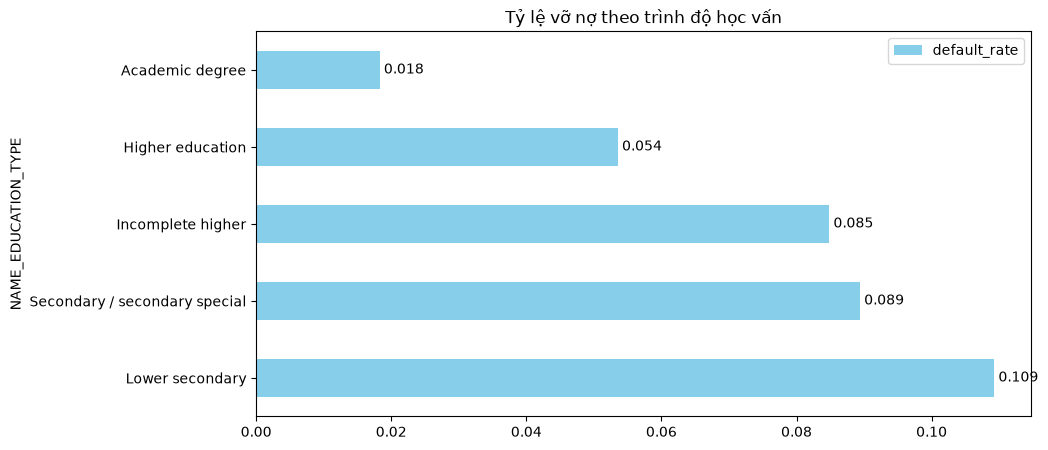

In [47]:
#CHUYỂN SANG PANDAS

df1 = df[["SK_ID_CURR", "TARGET", "CODE_GENDER", "NAME_CONTRACT_TYPE", "AMT_INCOME_TOTAL", "AMT_CREDIT","NAME_EDUCATION_TYPE" ]]
df2 = df1.groupby("NAME_EDUCATION_TYPE")["TARGET"].mean().reset_index(name ="default_rate").sort_values(by="default_rate", ascending = False)
ax = df2.set_index("NAME_EDUCATION_TYPE").plot(
    kind="barh",  
    title="Tỷ lệ vỡ nợ theo trình độ học vấn",
    figsize=(10, 5), # (Chiều rộng, Chiều cao) của khung hình
    color="skyblue"
)

# Dùng ax.containers[0] để lấy ra tập hợp các thanh cột vừa vẽ
ax.bar_label(
    ax.containers[0],          
    fmt='%.3f',                # Làm tròn 3 chữ số thập phân (VD: 0.109)
    padding=3                  # Khoảng cách từ số đến cái cột (cho đỡ dính vào nhau)
)
plt.show()

**Insight (áp Khung 4 bước):** So với gì? Độ lớn thế nào? Vì sao? Ảnh hưởng gì?

_(viết câu trả lời ở đây)_

So sánh giữa các nhóm học vấn, chúng ta thấy lần lượt nhóm Lower secondary (Trung học cơ sở) là có tỷ lệ vỡ nợ cao nhất (10,92%), nhóm có tỷ lệ vỡ nợ thấp nhất là nhóm Academic degree (Thạc sĩ, tiến sĩ) (1,83%).

Tại sao lại có kết quả như vậy?
- nếu xét góc độ học vấn thì nhóm này là nhóm không có thu nhập ổn định để trả nợ tín dụng. Bởi vì họ sẽ khó kiếm được công việc lương cao để trả nợ. Ít công ty lương cao tuyển người tốt nghiệp cấp 2. 
- Nhóm có bằng cấp 3 và Incomplete higher cũng có thể có lý do tương tự, dù tỷ lệ ít hơn (8~9%) nhưng k có nghĩa là tỷ lệ này không cao. Tuy nhiên 3 nhóm trên thường có nhu cầu vay nhiều hơn do mưu sinh sớm hơn. 
-  Với nhóm Đại học (Higher education), tỷ lệ vỡ nợ của họ (5.35%) thực chất là rất thấp so với mặt bằng chung. Thay vì cố đi tìm lý do "tại sao họ vỡ nợ" (như ý có trợ cấp nhưng vẫn vay...), bạn nên giải thích "tại sao nhóm này lại an toàn và ít vỡ nợ hơn". Trọng tâm nên là: Họ có công việc tốt hơn, lương cao/ổn định hơn và có kiến thức quản lý tài chính cá nhân (financial literacy) tốt hơn


Điều này có gây ảnh hưởng gì đến cuộc sống?

theo tôi nó chỉ phản ánh đúng cuộc sống. Tuy nhiên, việc bằng cấp thấp đi kèm với tỷ lệ vỡ nợ cao thể hiện rằng tổ chức tài chính cần xét duyệt các khoản vay kĩ hơn, liên quan thu nhập, bằng cấp, lãi suất cao hơn, kiểm soát hạn mức cho vay.  NGược lại có thể tung các gói vay ưu đãi để thu hút nhóm tệp khách hàng đại học hay thạc sĩ, tiến sĩ. 

CHỮA BÀI 


### 1. Nhận xét chi tiết theo khung:

*   **So với gì? Độ lớn thế nào? (Observation)**
    *   *Điểm tốt:* Bạn đã nêu bật được cực đại (Lower secondary - 10.92%) và cực tiểu (Academic degree - 1.83%).
    *   *Nên bổ sung:* Nên chỉ ra được **xu hướng chung (trend)**. Bảng dữ liệu này thể hiện một mối tương quan tuyến tính rất đẹp: *Học vấn càng cao, tỷ lệ vỡ nợ càng giảm.* Việc nêu ra xu hướng này quan trọng hơn việc chỉ liệt kê điểm cao/thấp.
*   **Vì sao? (Root cause)**
    *   *Điểm tốt:* Lý giải cho nhóm Cấp 2, Cấp 3 (thu nhập bấp bênh, khó xin việc, mưu sinh sớm) là rất thực tế và hợp lý.
    *   *Điểm cần chỉnh sửa:* Với nhóm Đại học (Higher education), tỷ lệ vỡ nợ của họ (5.35%) thực chất là **rất thấp** so với mặt bằng chung. Thay vì cố đi tìm lý do "tại sao họ vỡ nợ" (như ý *có trợ cấp nhưng vẫn vay...*), bạn nên giải thích **"tại sao nhóm này lại an toàn và ít vỡ nợ hơn"**. Trọng tâm nên là: Họ có công việc tốt hơn, lương cao/ổn định hơn và có kiến thức quản lý tài chính cá nhân (financial literacy) tốt hơn.
*   **Ảnh hưởng gì? (Business Impact / Action)**
    *   *Điểm tốt:* Đã đưa ra được hành động (action) cụ thể cho tổ chức tài chính là "cần xét duyệt kĩ hơn". 
    *   *Nên bổ sung:* Hãy làm cho Action này cụ thể hơn bằng ngôn ngữ của ngành tài chính (Ví dụ: tính lãi suất cao hơn, giảm hạn mức,...).

---

### 2. Gợi ý bài viết hoàn chỉnh (Bạn có thể tham khảo):

**Insight (áp Khung 4 bước):**

**1. So sánh & Độ lớn:**
Nhìn vào dữ liệu, có một xu hướng tỷ lệ nghịch rất rõ ràng: **Trình độ học vấn càng cao thì tỷ lệ rủi ro vỡ nợ càng thấp.** Cụ thể, nhóm Lower secondary (Cấp 2) có tỷ lệ vỡ nợ cao nhất lên tới gần 11%. Tỷ lệ này giảm dần qua các cấp bậc và đạt mức thấp nhất ở nhóm Academic degree (Thạc sĩ/Tiến sĩ) với chỉ vỏn vẹn 1.83%.

**2. Vì sao lại như vậy?**
*   **Với nhóm học vấn thấp (Lower Secondary / Secondary):** Họ thường làm các công việc phổ thông, thu nhập thấp và thiếu tính ổn định. Ngoài ra, việc phải lăn lộn mưu sinh sớm có thể dẫn đến nhu cầu vay mượn cao nhưng lại thiếu đi kỹ năng quản lý tài chính cá nhân, dẫn đến mất khả năng trả nợ.
*   **Với nhóm học vấn cao (Higher Education / Academic degree):** Ngược lại, nhóm này có ưu thế cạnh tranh trên thị trường lao động, sở hữu công việc chuyên môn với thu nhập cao và dòng tiền ổn định. Họ cũng có nhận thức và kỹ năng quy hoạch tài chính cá nhân tốt hơn, giúp duy trì lịch sử tín dụng sạch.

**3. Ảnh hưởng và Hành động (Business Action):**
Biến "Học vấn" là một tín hiệu (feature) cực kỳ quan trọng trong mô hình chấm điểm tín dụng (Credit Scoring). Tổ chức tài chính có thể áp dụng các chính sách sau:
*   **Phân luồng rủi ro:** Phân loại nhóm Lower Secondary/Secondary vào tệp rủi ro cao (High-risk). 
*   **Thiết kế sản phẩm:** Khi cấp tín dụng cho nhóm này, hệ thống cần yêu cầu thêm giấy tờ chứng minh thu nhập, áp dụng hạn mức tín dụng (Credit Limit) thấp hơn, hoặc thu mức lãi suất cao hơn (Risk-based pricing) để bù đắp rủi ro tiềm ẩn. Ngược lại, có thể tung các gói vay ưu đãi để thu hút nhóm tệp khách hàng "ngon" như Higher Education/Academic.

### Câu 2 — Top 10% thu nhập cao nhất nhưng vẫn vỡ nợ
Tìm nhóm khách hàng thuộc top 10% thu nhập (`AMT_INCOME_TOTAL`) cao nhất, trong đó bao nhiêu % vẫn vỡ nợ (`TARGET = 1`)?

*Dùng `NTILE(10)` (SQL) hoặc `pd.qcut`/`quantile` (pandas) — đây là chỗ bạn từng vướng.*


In [67]:
duckdb.sql("""
WITH incomer AS(
SELECT SK_ID_CURR, TARGET, AMT_INCOME_TOTAL, NTILE(10) OVER (ORDER BY AMT_INCOME_TOTAL DESC) as income_rank
FROM df1)
SELECT AVG(TARGET) as default_rate_high_incomer
FROM incomer 
WHERE income_rank = 1
""")


┌───────────────────────────┐
│ default_rate_high_incomer │
│          double           │
├───────────────────────────┤
│       0.06256503642039542 │
└───────────────────────────┘

In [ ]:
#CÁCH NTILE k hợp lý. 
#Cách 2

# Sử dụng thử cách Percent_rank()

duckdb.sql("""
WITH income_ranked AS (
    SELECT TARGET, PERCENT_RANK() OVER (ORDER BY AMT_INCOME_TOTAL ASC) AS pct_rank
    FROM df1
)
SELECT AVG(TARGET) AS DEFAULT_RATE
FROM income_ranked

WHERE pct_rank >= 0.9
""")

┌──────────────────────┐
│     DEFAULT_RATE     │
│        double        │
├──────────────────────┤
│ 0.061374765288465076 │
└──────────────────────┘

In [ ]:
#Cách 3: 
duckdb.sql("""WITH muc_chuan AS (
    -- Tìm ra mức thu nhập chuẩn của mốc 90% (Top 10%)
    SELECT 
        PERCENTILE_CONT(0.9) WITHIN GROUP (ORDER BY AMT_INCOME_TOTAL) AS top_10_threshold
    FROM df1
)
SELECT 
    AVG(df1.TARGET) AS default_rate
FROM df1, muc_chuan
-- Lấy tất cả những ai có thu nhập >= mức chuẩn (Sẽ lấy trọn gói những người bằng nhau)
WHERE df1.AMT_INCOME_TOTAL >= muc_chuan.top_10_threshold;
""")

┌────────────────────┐
│    default_rate    │
│       double       │
├────────────────────┤
│ 0.0636516794777298 │
└────────────────────┘

In [54]:
df1.describe() #mean target = 0.08 => tỷ lệ vỡ nợ trung bình 8%.
df1

,SK_ID_CURR,TARGET,CODE_GENDER,NAME_CONTRACT_TYPE,AMT_INCOME_TOTAL,AMT_CREDIT,NAME_EDUCATION_TYPE
0,100002,1,M,Cash loans,202500.0,406597.5,Secondary / secondary special
1,100003,0,F,Cash loans,270000.0,1293502.5,Higher education
2,100004,0,M,Revolving loans,67500.0,135000.0,Secondary / secondary special
3,100006,0,F,Cash loans,135000.0,312682.5,Secondary / secondary special
4,100007,0,M,Cash loans,121500.0,513000.0,Secondary / secondary special
...,...,...,...,...,...,...,...
307506,456251,0,M,Cash loans,157500.0,254700.0,Secondary / secondary special
307507,456252,0,F,Cash loans,72000.0,269550.0,Secondary / secondary special
307508,456253,0,F,Cash loans,153000.0,677664.0,Higher education
307509,456254,1,F,Cash loans,171000.0,370107.0,Secondary / secondary special


In [ ]:
#CHUYỂN SANG PANDAS SẼ NHƯ THẾ NÀO? Hàm quantile đếm từ dưới lên. Giống hàm percentile_cont. 
muc_thu_nhap_top_10 = df1["AMT_INCOME_TOTAL"].quantile(0.9) #NUMBER
df_sieu_giau = df1[df1["AMT_INCOME_TOTAL"] >=muc_thu_nhap_top_10]
print(df_sieu_giau["TARGET"].mean())


0.0636516794777298


**Insight:** Thu nhập cao có thực sự bảo vệ khỏi vỡ nợ không? Vì sao con số này có ý nghĩa hay không?

DÙNG  KHUNG 4 BƯƠC THÌ SẼ LÀ NTN. CON SỐ ĐẠT 6,2% , MỘT CON SỐ KHÔNG QUÁ LỚN. THỂ HIỆN RẰNG TRONG 1000 NGƯỜI GIÀU THÌ CÓ 62 NGƯỜI VỠ NỢ. 

CHỨNG TỎ THU NHẬP CAO K ẢNH HƯỞNG KHẢ NĂNG VỠ NỢ. NHỮNG NHÓM NGƯỜI VƠ NỢ KH THU NHẬ CAO CÓ THỂ LÀ DO VIỆC KINH DOANH HÁ SẢN, ĐI TÙ, HAY VIỆC SỬ DỤNG CÁC ĐÒN BẨY TÀI CHÍNH GÂY RỦI RO CAO. 
ĐIỀU NÀY THEO TÔI CHƯA GÂY ẢNH HƯỞNG GI QUÁ LỚN ĐẾN BÁO CÁO . 

CHỮA LẠI  
Bài viết của bạn đã nắm bắt được ý chính và có cách diễn đạt rất hay (quy đổi thành "62 người trên 1000 người"). Tuy nhiên, nếu áp dụng chuẩn **Khung 4 bước** và tư duy phân tích dữ liệu, bài của bạn đang mắc **1 lỗi logic lớn** và phần kết luận (Ảnh hưởng) đang hơi bị "cụt".

Để mình phân tích và giúp bạn gọt giũa lại nhé:

### 1. Điểm cần chỉnh sửa trong bài của bạn:

*   **Lỗi logic ở câu:** *"CHỨNG TỎ THU NHẬP CAO KHÔNG ẢNH HƯỞNG KHẢ NĂNG VỠ NỢ"* 
    *   **Thực tế:** Tỷ lệ vỡ nợ trung bình của toàn bộ khách hàng (cả giàu lẫn nghèo) thường rơi vào khoảng **8% - 8.5%**. Nhóm siêu giàu chỉ có **6.2%**. Rõ ràng là 6.2% thấp hơn 8%, tức là thu nhập cao **CÓ ẢNH HƯỞNG** (giúp giảm rủi ro vỡ nợ). Bạn chỉ nên nói là *"Thu nhập cao giúp giảm rủi ro, nhưng không loại bỏ hoàn toàn rủi ro"*.
*   **Điểm yếu ở phần Ảnh hưởng:** *"CHƯA GÂY ẢNH HƯỞNG GÌ QUÁ LỚN ĐẾN BÁO CÁO"*
    *   **Thực tế:** Trong doanh nghiệp, Data Analyst không viết ra 1 insight rồi kết luận là "nó không có ảnh hưởng gì". Bước 4 (Ảnh hưởng gì) là bước yêu cầu bạn phải đưa ra được **Đề xuất hành động (Action)** cho công ty/ngân hàng. Nếu 1000 ông giàu mà có 62 ông bùng nợ (mỗi ông vay vài tỷ) thì ngân hàng thiệt hại vô cùng lớn. Vậy ngân hàng phải làm gì?

---

### 2. Viết lại theo chuẩn Khung 4 bước (dựa trên ý của bạn):

Bạn có thể tham khảo cách trình bày sau để đưa vào Notebook:

**1. So với gì? Độ lớn thế nào?**
Tại nhóm 10% khách hàng có thu nhập cao nhất, tỷ lệ vỡ nợ ghi nhận ở mức 6,2% (thấp hơn so với mức trung bình của toàn hệ thống là khoảng 8%). Mặc dù không quá lớn, nhưng con số này thể hiện rằng: Cứ 1.000 người siêu giàu thì vẫn có tới 62 người mất khả năng trả nợ.

**2. Vì sao lại như vậy?**
Thu nhập cao giúp giảm tỷ lệ vỡ nợ chung, nhưng không bảo vệ khách hàng khỏi rủi ro tuyệt đối. Nhóm vỡ nợ trong tệp thu nhập cao này có thể đến từ các nguyên nhân phi thu nhập như: Kinh doanh phá sản, rủi ro pháp lý (đi tù, lừa đảo), hoặc do họ lạm dụng các đòn bẩy tài chính (vay đầu tư chứng khoán, bất động sản quá tay) dẫn đến đứt gãy dòng tiền thanh khoản.

**3. Ảnh hưởng và Hành động đề xuất (Business Impact/Action)?**
Insight này mang lại giá trị cảnh báo lớn cho hệ thống tín dụng: Ngân hàng **không được phép nới lỏng hoặc bỏ qua các quy trình thẩm định** chỉ vì khách hàng khai báo thu nhập khủng. 
Thay vì chỉ dựa vào `AMT_INCOME_TOTAL`, ngân hàng cần đánh giá chéo thêm các chỉ số khác như: Lịch sử tín dụng (CIC), Tỷ lệ nợ trên thu nhập (DTI - Debt to Income), và tính ổn định của nguồn thu (làm thuê hay làm chủ) trước khi phê duyệt các khoản vay hạn mức lớn cho nhóm này.

### Câu 3 — Tỷ lệ Credit/Income và khả năng vỡ nợ
Tạo cột `CREDIT_INCOME_RATIO = AMT_CREDIT / AMT_INCOME_TOTAL`. So sánh tỷ lệ vỡ nợ giữa nhóm có tỷ lệ này cao (trên median) và nhóm thấp (dưới median).


**Insight:** Độ lớn khác biệt giữa 2 nhóm có đáng kể không? Đây có phải yếu tố rủi ro thực sự?

_(viết câu trả lời ở đây)_

---
## Phần 2 — Đào sâu hơn: nhiều chiều, window functions, tương quan


### Câu 4 — Xếp hạng độ tuổi rủi ro nhất
Tạo nhóm tuổi (chuyển `DAYS_BIRTH` thành tuổi), dùng `RANK()`/`ROW_NUMBER()` (SQL) hoặc `rank()` (pandas) để xếp hạng các nhóm tuổi theo tỷ lệ vỡ nợ, từ cao xuống thấp.


**Insight:** Nhóm tuổi nào rủi ro nhất? Có hợp lý theo trực giác không, hay bất ngờ?

_(viết câu trả lời ở đây)_

### Câu 5 — Tình trạng việc làm (DAYS_EMPLOYED) và rủi ro
So sánh tỷ lệ vỡ nợ giữa nhóm có thời gian làm việc (`DAYS_EMPLOYED`) lâu năm và nhóm mới đi làm. Lưu ý: dataset này có giá trị bất thường (outlier) ở cột này — kiểm tra trước khi phân tích.


**Insight:** Có phát hiện outlier không? Xử lý thế nào? Kết luận về mối liên hệ này?

_(viết câu trả lời ở đây)_

### Câu 6 — Loại hợp đồng vay (NAME_CONTRACT_TYPE)
So sánh tỷ lệ vỡ nợ giữa vay tiền mặt (Cash loans) và vay trả góp (Revolving loans).


**Insight:** Chênh lệch này lớn hay nhỏ? Nguyên nhân khả dĩ là gì?

_(viết câu trả lời ở đây)_

### Câu 7 — Tình trạng hôn nhân và số con
Tỷ lệ vỡ nợ có khác nhau giữa các nhóm `NAME_FAMILY_STATUS` không? Số con (`CNT_CHILDREN`) có tương quan với tỷ lệ vỡ nợ không?


**Insight:** Đây có phải yếu tố nên đưa vào mô hình rủi ro? Vì sao (cẩn thận với yếu tố nhạy cảm/đạo đức khi dùng thực tế)?

_(viết câu trả lời ở đây)_

### Câu 8 — Điểm ngoại sinh (EXT_SOURCE_1/2/3)
Dataset có 3 cột điểm tín dụng từ nguồn ngoài (`EXT_SOURCE_1`, `EXT_SOURCE_2`, `EXT_SOURCE_3`). Tính tương quan (correlation) giữa mỗi cột này với `TARGET`.


**Insight:** Cột nào tương quan mạnh nhất với vỡ nợ? Điều này gợi ý gì về việc dùng dữ liệu bên thứ 3 trong chấm điểm tín dụng?

_(viết câu trả lời ở đây)_

---
## Phần 3 — Tổng hợp & mở rộng


### Câu 9 — Kết hợp nhiều yếu tố
Chọn 2-3 yếu tố có vẻ ảnh hưởng nhất từ các câu trên, nhóm theo kết hợp của chúng (vd: học vấn × loại hợp đồng vay), tìm nhóm có tỷ lệ vỡ nợ cao nhất.


**Insight:** Nhóm rủi ro cao nhất là ai? Đây có phải phát hiện đủ rõ để đề xuất hành động (vd: siết điều kiện vay) không?

_(viết câu trả lời ở đây)_

### Câu 10 — Xu hướng hay nhiễu?
Chọn 1 phát hiện ở trên có vẻ bất ngờ. Kiểm tra: nhóm đó có đủ lớn (số lượng mẫu) để tin cậy không, hay có thể chỉ là nhiễu do mẫu nhỏ?


**Insight:** Áp dụng khái niệm thống kê "trend vs noise" — kết luận có đáng tin không?

_(viết câu trả lời ở đây)_

### Câu 11 — Nếu là chuyên viên rủi ro tín dụng
Dựa trên toàn bộ phân tích, viết 3 khuyến nghị ngắn (mỗi cái 1-2 câu) cho một ngân hàng muốn giảm tỷ lệ vỡ nợ, dựa trên các yếu tố bạn vừa tìm ra.


_(viết 3 khuyến nghị ở đây — đây chính là phần "Decision/Action" trong chuỗi giá trị Raw Data → ... → Action)_

### Câu 12 — Câu hỏi tự đặt thêm
Tự nghĩ ra 1 câu hỏi mới từ dữ liệu này mà chưa ai hỏi ở trên, dùng đúng Khung 4 bước để trả lời.


**Câu hỏi tự đặt:**

_(viết ở đây)_

**Insight:**

_(viết ở đây)_

---
## Kết luận chung

_(Tóm tắt 3-5 dòng: phát hiện quan trọng nhất, điều gì bất ngờ nhất, điều gì sẽ đưa vào README khi push lên GitHub)_
